## **Calculate and prepare logits train/test set for Inferno**

In [1]:
import torch
import pandas as pd
from torch.utils.data import DataLoader

from CNN import InfernoCalibNet, ChestXRayDataset, OUT_DIR, CALIB_DIR

def evaluate_and_prepare_inferno():
    torch.cuda.empty_cache()

    df_meta = pd.read_csv(OUT_DIR / "ml_test.csv")
    test_dt = ChestXRayDataset(OUT_DIR / "ml_test.csv", transform=False)
    test_loader = DataLoader(
        test_dt, batch_size=32, shuffle=False, num_workers=8, pin_memory=True
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=2).to(device)
    model.load_state_dict(torch.load(CALIB_DIR / "InfernoCalibNetML.pth", weights_only=True))
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            all_preds.append(outputs.cpu())
            all_targets.append(targets.cpu())

    preds_tensor = torch.cat(all_preds)
    targets_tensor = torch.cat(all_targets)

    df_meta = df_meta.reset_index(drop=True)
    df_meta["LOGIT_EFFUSION"] = preds_tensor[:, 0].numpy()
    df_meta["LABEL_EFFUSION"] = targets_tensor[:, 0].numpy().astype(int)
    df_meta["LOGIT_ATELECTASIS"] = preds_tensor[:, 1].numpy()
    df_meta["LABEL_ATELECTASIS"] = targets_tensor[:, 1].numpy().astype(int)

    df_meta.to_csv(CALIB_DIR / "calibration_full.csv", index=False)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    total_loss = loss_fn(preds_tensor, targets_tensor).item()

    return df_meta, preds_tensor, targets_tensor, total_loss

def stratified_sample(df, label_col, sample_size, seed=42):
    from sklearn.model_selection import train_test_split

    counts = df[label_col].value_counts()
    valid_classes = counts[counts >= 2].index
    filtered_df = df[df[label_col].isin(valid_classes)]

    stratified_df, remainder_df = train_test_split(
        filtered_df,
        train_size=sample_size,
        stratify=filtered_df[label_col],
        random_state=seed
    )
    return stratified_df, remainder_df


df, preds, targets, loss = evaluate_and_prepare_inferno()
sampled_df, remainder_df = stratified_sample(df, label_col="DISEASELABEL", sample_size=1500)
# sampled_df, remainder_df = stratified_sample(df, label_col="LABEL_ATELECTASIS", sample_size=1500)
# sampled_df.to_csv(CALIB_DIR  / "calibration_train.csv", index=False)
# remainder_df.to_csv(CALIB_DIR  / "calibration_test.csv", index=False)


## **Calculate and print metrics and it's graphs**

─────────────────────────────────────────────── Evaluation Metrics ────────────────────────────────────────────────

Test BCEWithLogitsLoss: 0.4411

                         Classification Metrics                         
┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃    Label    ┃ Precision ┃ Recall ┃ F1-score ┃  AUROC ┃ Avg Precision ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│  Effusion   │    0.7834 │ 0.6867 │   0.7319 │ 0.8904 │        0.7835 │
├─────────────┼───────────┼────────┼──────────┼────────┼───────────────┤
│ Atelectasis │    0.6356 │ 0.4886 │   0.5525 │ 0.7900 │        0.6266 │
└─────────────┴───────────┴────────┴──────────┴────────┴───────────────┘

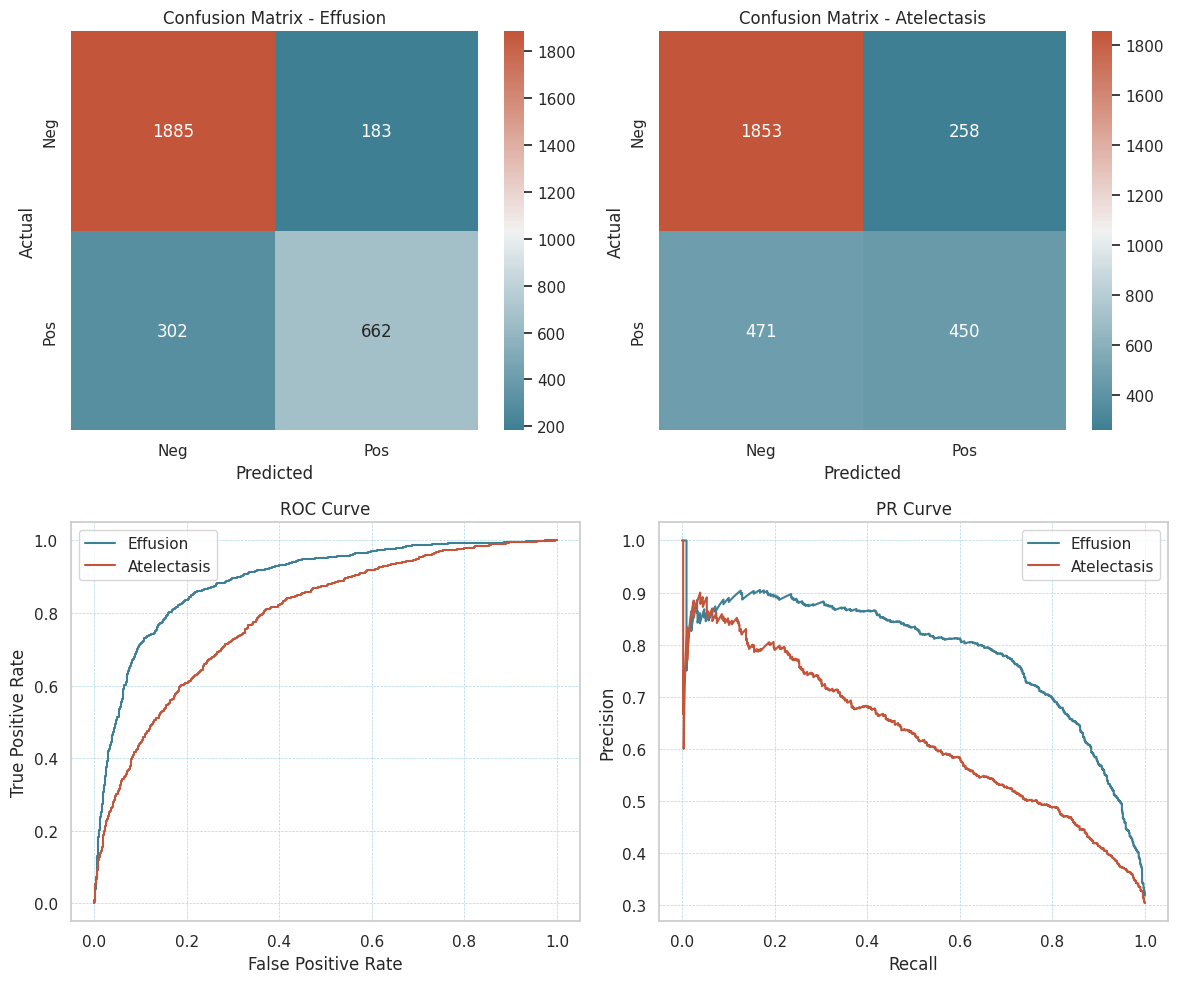

In [2]:
from rich.console import Console
from rich.table import Table

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

sns.set_theme(style="whitegrid", palette=sns.diverging_palette(220, 20, n=2))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

console = Console()

def runMetrics(preds_tensor, targets_tensor, avg_loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    console.rule("[bold cyan]Evaluation Metrics")
    console.print(f"Test BCEWithLogitsLoss: {avg_loss:.4f}")

    table = Table(title="Classification Metrics", show_lines=True)
    table.add_column("Label", justify="center")
    table.add_column("Precision", justify="right")
    table.add_column("Recall", justify="right")
    table.add_column("F1-score", justify="right")
    table.add_column("AUROC", justify="right")
    table.add_column("Avg Precision", justify="right")

    roc_data = {}
    pr_data = {}
    confusion_matrices = {}

    for i, label_name in zip([0, 1], ["Effusion", "Atelectasis"]):
        p = probs[:, i] > 0.5
        t = targets[:, i]

        prec = precision_score(t, p)
        rec = recall_score(t, p)
        f1 = f1_score(t, p)
        auroc = roc_auc_score(t, probs[:, i])
        ap = average_precision_score(t, probs[:, i])

        table.add_row(label_name, f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{auroc:.4f}", f"{ap:.4f}")

        fpr, tpr, _ = roc_curve(t, probs[:, i])
        prec_curve, rec_curve, _ = precision_recall_curve(t, probs[:, i])

        roc_data[label_name] = (fpr, tpr)
        pr_data[label_name] = (rec_curve, prec_curve)

        cm = confusion_matrix(t, p)
        confusion_matrices[label_name] = cm

    console.print(table)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for idx, (label, cm) in enumerate(confusion_matrices.items()):
        ax = axes[0, idx]
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
        ax.set_title(f"Confusion Matrix - {label}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    for idx, (label, (fpr, tpr)) in enumerate(roc_data.items()):
        axes[1, 0].plot(fpr, tpr, label=label)
    axes[1, 0].set_title("ROC Curve")
    axes[1, 0].set_xlabel("False Positive Rate")
    axes[1, 0].set_ylabel("True Positive Rate")
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', linewidth=0.5, color='lightblue')

    for idx, (label, (rec_curve, prec_curve)) in enumerate(pr_data.items()):
        axes[1, 1].plot(rec_curve, prec_curve, label=label)
    axes[1, 1].set_title("PR Curve")
    axes[1, 1].set_xlabel("Recall")
    axes[1, 1].set_ylabel("Precision")
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', linewidth=0.5, color='lightblue')

    plt.tight_layout()
    plt.show()

runMetrics(preds, targets, loss)


## **Confidence Score Distributions for Positive vs Negative Predictions**

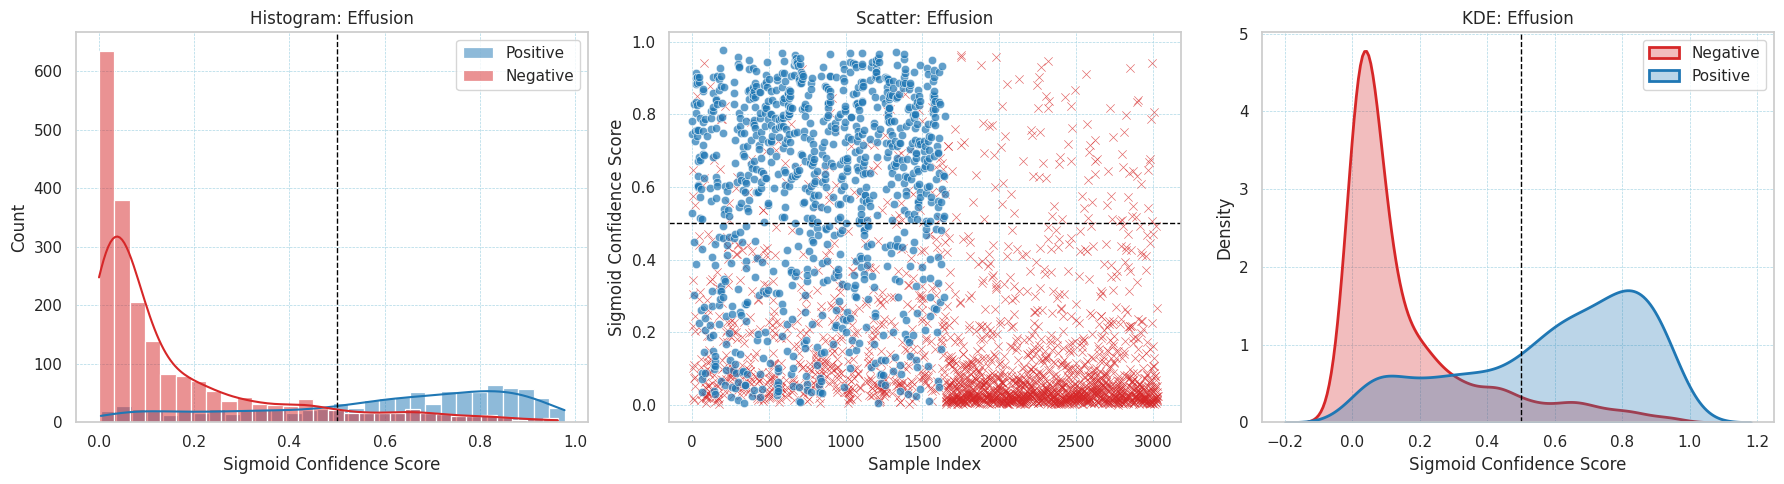

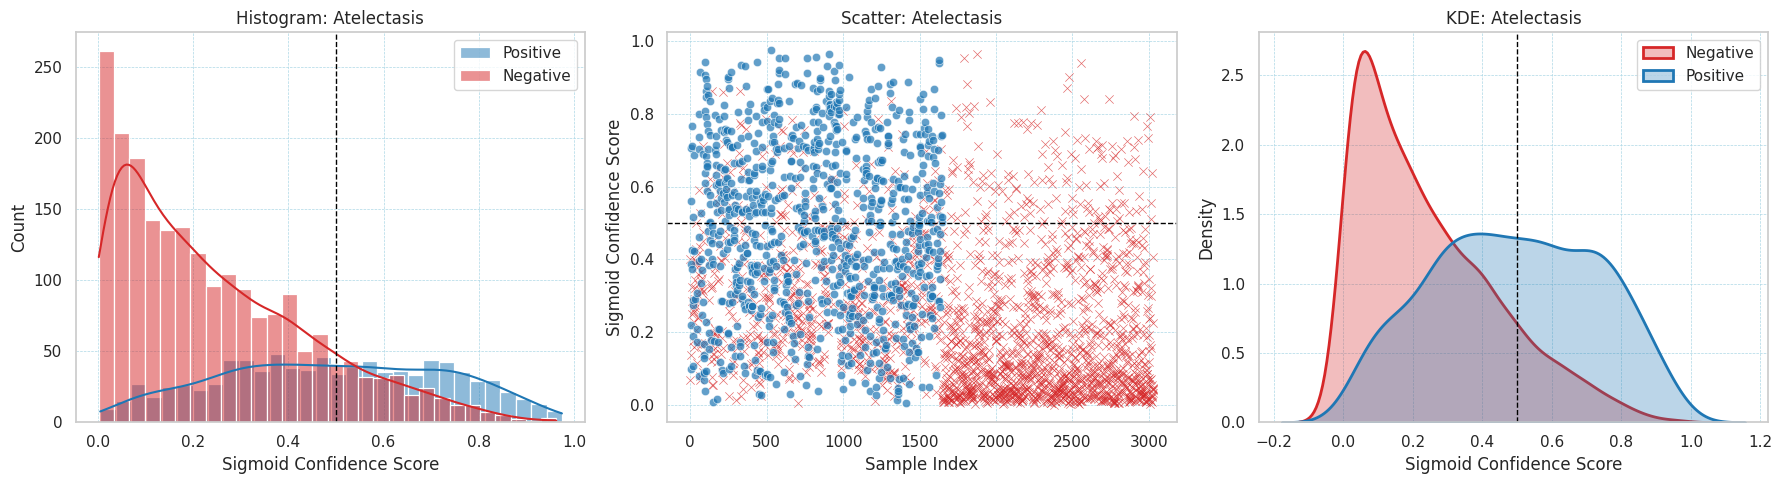

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette=sns.diverging_palette(220, 20, n=2),
    font='sans-serif',
    font_scale=1,
    color_codes=True,
    rc=None
)

def visualize_sigmoid_confidence(preds_tensor, targets_tensor):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    plt.rcParams['axes.grid'] = True
    plt.rc('grid', linestyle='--', linewidth=0.5, color='lightblue')

    for i, label in enumerate(["Effusion", "Atelectasis"]):
        p = probs[:, i]
        t = targets[:, i]

        plt.figure(figsize=(18, 5))

        # Histogram
        plt.subplot(1, 3, 1)
        sns.histplot(p[t == 1], bins=30, label="Positive", kde=True, alpha=0.5, color="#1f77b4")
        sns.histplot(p[t == 0], bins=30, label="Negative", kde=True, alpha=0.5, color="#d62728")
        plt.axvline(x=0.5, linestyle="--", color="black", linewidth=1)
        plt.xlabel("Sigmoid Confidence Score")
        plt.ylabel("Count")
        plt.title(f"Histogram: {label}")
        plt.legend()

        # Scatter
        plt.subplot(1, 3, 2)
        sns.scatterplot(x=np.arange(len(p))[t == 0], y=p[t == 0], marker='x', color="#d62728", alpha=0.7)
        sns.scatterplot(x=np.arange(len(p))[t == 1], y=p[t == 1], marker='o', color="#1f77b4", alpha=0.7)
        plt.axhline(y=0.5, linestyle="--", color="black", linewidth=1)
        plt.xlabel("Sample Index")
        plt.ylabel("Sigmoid Confidence Score")
        plt.title(f"Scatter: {label}")

        # KDE
        plt.subplot(1, 3, 3)
        sns.kdeplot(p[t == 0], label="Negative", fill=True, color="#d62728", alpha=0.3, linewidth=2)
        sns.kdeplot(p[t == 1], label="Positive", fill=True, color="#1f77b4", alpha=0.3, linewidth=2)
        plt.axvline(x=0.5, linestyle="--", color="black", linewidth=1)
        plt.xlabel("Sigmoid Confidence Score")
        plt.ylabel("Density")
        plt.title(f"KDE: {label}")
        plt.legend()

        plt.tight_layout()
        plt.show()

visualize_sigmoid_confidence(preds, targets)